# 04 - Model Evaluation and Selection

Evaluates all 4 models on the **validation set** (accuracy, F1 macro, false alarm rate, confusion matrix), selects the best by F1 macro, evaluates it **once on the test set**, and checks the criterion `F1 macro >= 0.90`. Generates a learning curve and Random Forest feature importance. Figures saved to `outputs/pilot/modeling/`.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
for ROOT in [_p, *_p.parents]:
    if (ROOT / "requirements.txt").exists():
        break
sys.path.insert(0, str(ROOT / "src"))

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import learning_curve

from preprocessing import load_feature_table, split_features_metadata
from evaluation import compute_metrics, plot_confusion_matrix

SPLITS_DIR = ROOT / "data" / "splits"
MODELS_DIR = ROOT / "models"
OUT_DIR = ROOT / "outputs" / "pilot" / "modeling"
OUT_DIR.mkdir(parents=True, exist_ok=True)
F1_THRESHOLD = 0.90
MODEL_NAMES = ["random_forest", "svm", "gradient_boosting", "mlp"]

In [2]:
val = load_feature_table(SPLITS_DIR / "val.parquet")
test = load_feature_table(SPLITS_DIR / "test.parquet")
X_val, y_val, _ = split_features_metadata(val)
X_test, y_test, _ = split_features_metadata(test)

scaler = joblib.load(MODELS_DIR / "scaler.pkl")
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
models = {n: joblib.load(MODELS_DIR / f"{n}.pkl") for n in MODEL_NAMES}

In [3]:
val_rows = [{"model": n, **compute_metrics(y_val, m.predict(X_val_s))}
            for n, m in models.items()]
val_metrics = (pd.DataFrame(val_rows)
               .sort_values("f1_macro", ascending=False).reset_index(drop=True))
val_metrics

,model,accuracy,f1_macro,false_alarm_rate
0,svm,1.000000,1.000000,0.0
1,random_forest,0.994444,0.994444,0.0
2,gradient_boosting,0.994444,0.994444,0.0
3,mlp,0.994444,0.994444,0.0


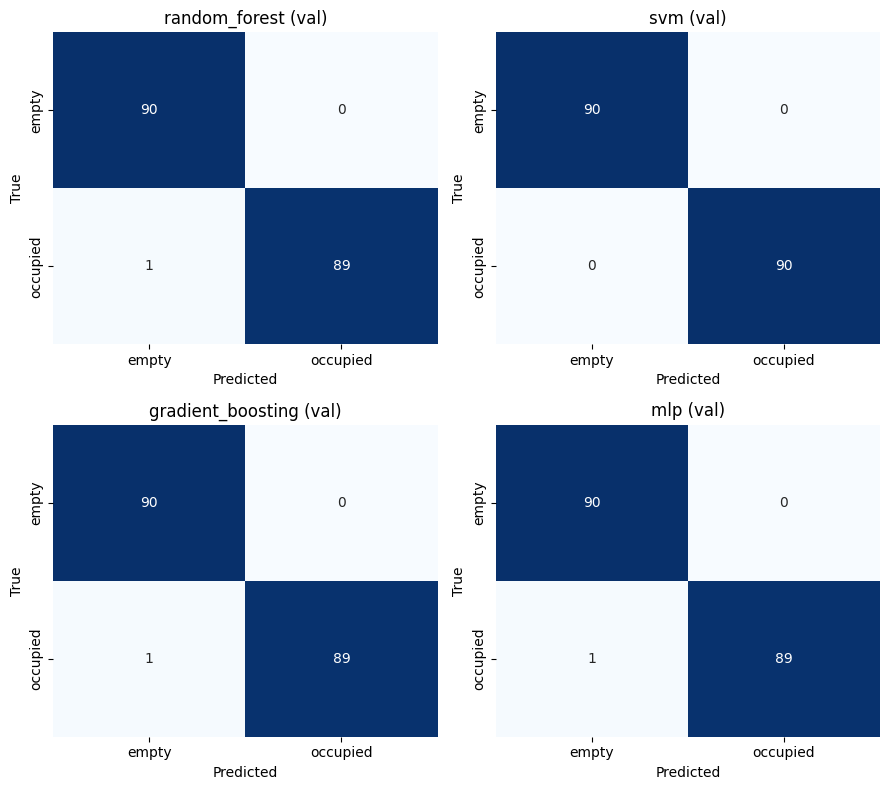

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (name, model) in zip(axes.ravel(), models.items()):
    plot_confusion_matrix(y_val, model.predict(X_val_s), ax=ax, title=f"{name} (val)")
fig.tight_layout()
fig.savefig(OUT_DIR / "confusion_matrices_val.png", dpi=150)
plt.show()

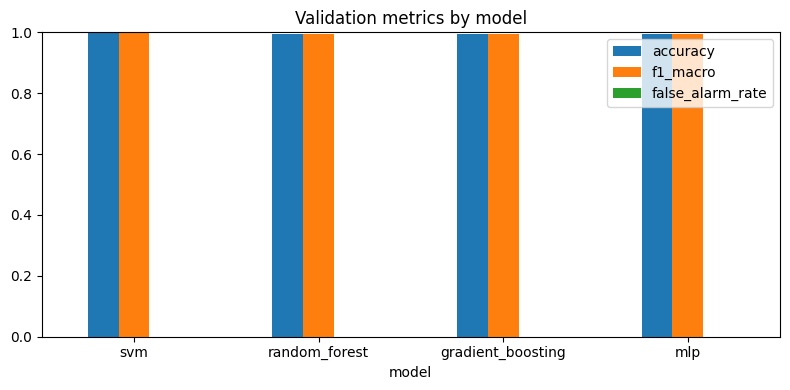

In [5]:
ax = (val_metrics.set_index("model")[["accuracy", "f1_macro", "false_alarm_rate"]]
      .plot.bar(figsize=(8, 4), rot=0))
ax.set_title("Validation metrics by model")
ax.set_ylim(0, 1)
ax.figure.tight_layout()
ax.figure.savefig(OUT_DIR / "model_comparison_val.png", dpi=150)
plt.show()

In [6]:
best_name = val_metrics.iloc[0]["model"]
best_model = models[best_name]
print("best model by val f1_macro:", best_name)

test_metrics = compute_metrics(y_test, best_model.predict(X_test_s))
print("TEST metrics:", {k: round(v, 4) for k, v in test_metrics.items()})

passed = test_metrics["f1_macro"] >= F1_THRESHOLD
print(f"criterion f1_macro >= {F1_THRESHOLD}:", "PASS" if passed else "FAIL")

best model by val f1_macro: svm
TEST metrics: {'accuracy': 0.9944, 'f1_macro': 0.9944, 'false_alarm_rate': 0.0}
criterion f1_macro >= 0.9: PASS


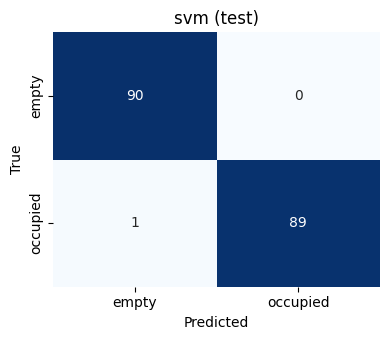

In [7]:
ax = plot_confusion_matrix(y_test, best_model.predict(X_test_s), title=f"{best_name} (test)")
ax.figure.tight_layout()
ax.figure.savefig(OUT_DIR / "confusion_matrix_test.png", dpi=150)
plt.show()

In [8]:
report = {
    "validation": val_metrics.to_dict(orient="records"),
    "best_model": best_name,
    "test": test_metrics,
    "f1_threshold": F1_THRESHOLD,
    "test_passed": bool(passed),
}
(OUT_DIR / "metrics_report.json").write_text(json.dumps(report, indent=2, default=float))
val_metrics.assign(split="val").to_csv(OUT_DIR / "metrics_report.csv", index=False)
print("saved metrics report to", OUT_DIR)

saved metrics report to /home/xavier/code/wifi-csi-presence-detection/outputs/pilot/modeling


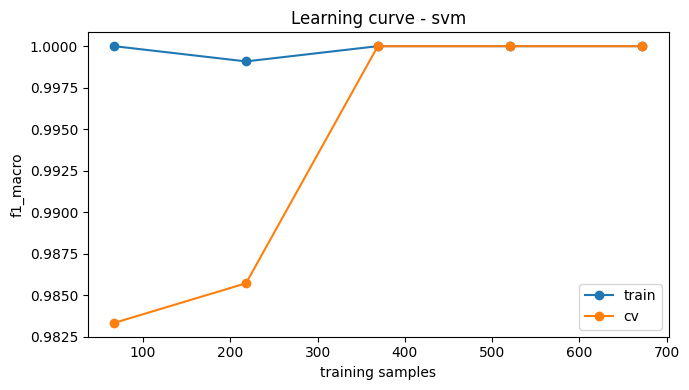

In [9]:
# Learning curve for the best model (on scaled training data).
train = load_feature_table(SPLITS_DIR / "train.parquet")
X_train, y_train, _ = split_features_metadata(train)
X_train_s = scaler.transform(X_train)

sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_s, y_train, cv=5, scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1,
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, train_scores.mean(axis=1), "o-", label="train")
ax.plot(sizes, val_scores.mean(axis=1), "o-", label="cv")
ax.set_xlabel("training samples")
ax.set_ylabel("f1_macro")
ax.set_title(f"Learning curve - {best_name}")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "learning_curve.png", dpi=150)
plt.show()

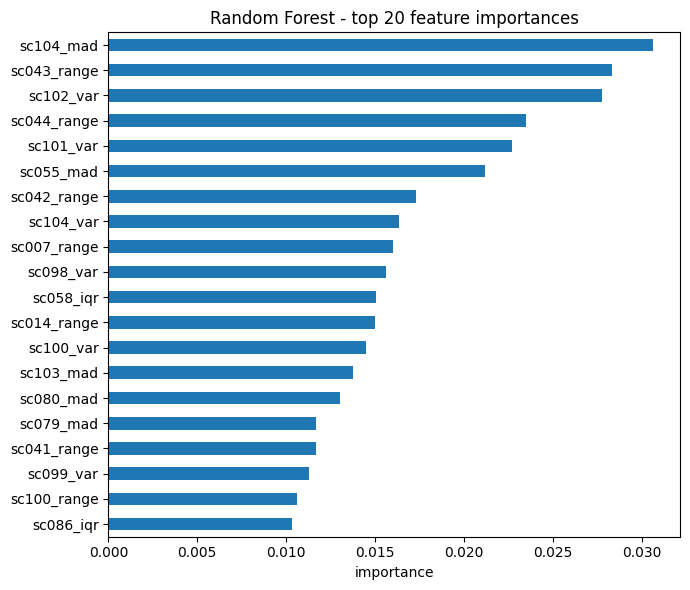

In [10]:
# Feature importance from the Random Forest (always available).
rf = models["random_forest"]
importances = (pd.Series(rf.feature_importances_, index=X_val.columns)
               .sort_values(ascending=False))
top = importances.head(20)
fig, ax = plt.subplots(figsize=(7, 6))
top.iloc[::-1].plot.barh(ax=ax)
ax.set_title("Random Forest - top 20 feature importances")
ax.set_xlabel("importance")
fig.tight_layout()
fig.savefig(OUT_DIR / "rf_feature_importance.png", dpi=150)
plt.show()

In [11]:
assert passed, f"best model test f1_macro={test_metrics['f1_macro']:.4f} < {F1_THRESHOLD}"
print(f"OK - criterion met: test f1_macro={test_metrics['f1_macro']:.4f} >= {F1_THRESHOLD}")

OK - criterion met: test f1_macro=0.9944 >= 0.9
